# Manifest explorer

The generator does not write audio. It writes a **manifest**: one CSV row per trial, holding every random choice that trial needs - which speakers, which recordings, when each one starts talking, how loud, which room, which noise clip. A renderer reads a row and produces exactly one mixture from it.

This notebook reads a manifest and explains what is in it, one theme at a time, so the recipe is understood before any audio exists.

Point `SPLIT` at any manifest in `data/manifests/` and re-run. Nothing below is specific to one split.

In [1]:
from pathlib import Path
from types import SimpleNamespace
import hashlib
import math
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

In [2]:
RANGES = {"mixture_length_s": "mixture_length_s", "overlap_requested": "overlap_ratio",
        "sir_db": "sir_db", "snr_db": "snr_db",
        "target_loudness_lufs": "target_loudness_lufs", "t60_s": "t60_s",
        "room_l": "room_length_m", "room_w": "room_width_m",
        "room_h": "room_height_m", "mic_z": "mic_height_m",
        "target_z": "source_height_m", "interferer_z": "source_height_m"}

## 0. Setup

Loads four things for the chosen split:

| | |
|---|---|
| **manifest** | `data/manifests/<split>.csv` — the trials |
| **meta** | `<split>.meta.yaml` — when it was built, from which commit and seed |
| **generator settings** | the `defaults` + this split's overrides from the config, so we can check the manifest against the ranges it was told to sample |
| **indexes** | `data/index/` — every LibriSpeech utterance (speaker, duration, transcript) and every noise clip. The manifest stores only IDs, so durations and text are looked up here |

In [3]:
# Which manifest to analyse. Works for smoke_train, smoke_val, train, val,
# eval_public, eval_private, or a scratch manifest via MANIFEST_PATH.

SPLIT = "smoke_train"
MANIFEST_PATH = None      # full path to a .csv; overrides SPLIT when set

In [4]:

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 100)

# The generator packs multi-value fields as "a|b|c". These become real lists.
LIST_COLS = {
    "target_utts": "target_utt_list",
    "target_onsets_s": "target_onset_list",
    "interferer_utts": "interferer_utt_list",
    "interferer_onsets_s": "interferer_onset_list",
}

# Columns pandas must NOT type-infer.
#   IDs: "0090" would become the int 90 and stop matching the folder on disk.
#   Packed fields: if no row in a manifest happens to contain a "|", the column
#   looks numeric and is read as float64 -- then the parse below sees a float
#   instead of a string and yields [] for every row, silently dropping every
#   onset. Content-dependent dtypes break when the content changes.
STR_COLS = {c: str for c in [
    "target_speaker", "interferer_speaker", "target_chapter", "interferer_chapter",
    *LIST_COLS,
]}


def find_root(start=None):
    """Walk up until CLAUDE.md appears, so paths resolve whether the kernel
    started in src/exploratory/ or at the repo root."""
    here = (start or Path.cwd()).resolve()
    for d in [here, *here.parents]:
        if (d / "CLAUDE.md").exists():
            return d
    raise RuntimeError(f"repo root not found above {here}")


ROOT = find_root()


def _as_list(cell):
    """"a|b" -> ["a", "b"]. Empty or missing -> []. Target-absent trials
    genuinely have no target utterances, so [] is a real value, not a bug."""
    if not isinstance(cell, str) or not cell.strip():
        return []
    return cell.split("|")


def load(split, manifest_path=None):
    """Everything needed to analyse one split, bundled together."""
    man = Path(manifest_path) if manifest_path else ROOT / "data/manifests" / f"{split}.csv"
    df = pd.read_csv(man, dtype=STR_COLS)
    columns = list(df.columns)

    for raw, parsed in LIST_COLS.items():
        vals = df[raw].map(_as_list)
        df[parsed] = vals if raw.endswith("_utts") else vals.map(
            lambda v: [float(x) for x in v])
        # A populated field that parsed to nothing means the parse is broken,
        # not that the trial is empty. Fail loudly rather than analyse zeros.
        broke = df[raw].notna() & (df[parsed].str.len() == 0)
        assert not broke.any(), f"{raw}: {int(broke.sum())} rows failed to parse"

    # One onset per utterance, or the two lists cannot be zipped meaningfully.
    for who in ("target", "interferer"):
        assert (df[f"{who}_utt_list"].str.len()
                == df[f"{who}_onset_list"].str.len()).all(), f"{who}: length mismatch"

    meta = yaml.safe_load(man.with_suffix(".meta.yaml").read_text())

    cfg_file = ROOT / meta["config"]
    config = yaml.safe_load(cfg_file.read_text())
    cfg = {**config["defaults"], **config["splits"].get(split, {})}
    cfg["seed"], cfg["sample_rate"] = config["seed"], config["sample_rate"]
    # If the config changed after the manifest was written, the ranges we check
    # against are not the ranges that were actually sampled from.
    stale = hashlib.md5(cfg_file.read_bytes()).hexdigest() != meta.get("config_md5")

    idx = ROOT / "data/index"
    utt_file = idx / f"utterances_{split}.csv"
    utts = (pd.read_csv(utt_file, dtype={"speaker": str, "chapter": str}).set_index("utt")
            if utt_file.exists() else None)
    noise_file = idx / f"noise_{cfg['noise_split']}.csv"
    noise = pd.read_csv(noise_file).set_index("clip") if noise_file.exists() else None

    # Onsets alone do not say when a speaker stops. Attach each chosen
    # utterance's length so talking intervals can be reconstructed.
    if utts is not None:
        dur = utts["duration"].to_dict()
        for who in ("target", "interferer"):
            df[f"{who}_dur_list"] = df[f"{who}_utt_list"].map(
                lambda us: [dur[u] for u in us])

    return SimpleNamespace(split=split, path=man, df=df, columns=columns,
                           meta=meta, cfg=cfg, utts=utts, noise=noise,
                           config_stale=stale)


def spans(row, who):
    """When `who` is actually talking, as [(start_s, end_s), ...]."""
    return [(o, o + d) for o, d in
            zip(row[f"{who}_onset_list"], row[f"{who}_dur_list"])]


def text_of(D, row, who):
    """The words spoken by `who` in this trial, in order."""
    return " ".join(D.utts.loc[u, "text"] for u in row[f"{who}_utt_list"])

In [5]:
D = load(SPLIT, MANIFEST_PATH)

print(f"{D.path.relative_to(ROOT)}")
print(f"  {len(D.df)} trials, {len(D.columns)} columns")
print(f"  built {D.meta['generated']}  seed {D.meta['seed']}  "
      f"commit {D.meta['git_commit'][:7]}  unsatisfiable {D.meta['n_failed']}")
print(f"  generator {D.meta['config']}"
      + ("   ** CHANGED since build — ranges below may not match **"
         if D.config_stale else "   (unchanged since build)"))
print(f"  utterance index  {'loaded' if D.utts is not None else 'MISSING'}"
      f"   ({len(D.utts)} utterances)" if D.utts is not None else "")
print(f"  noise index      {'loaded' if D.noise is not None else 'MISSING'}"
      f"   ({len(D.noise)} clips, WHAM! split '{D.cfg['noise_split']}')"
      if D.noise is not None else "")

data/manifests/smoke_train.csv
  50 trials, 41 columns
  built 2026-08-10  seed 42  commit 9d1c68b  unsatisfiable 0
  generator experiments/configs/generator.yaml   (unchanged since build)
  utterance index  loaded   (2239 utterances)
  noise index      loaded   (20000 clips, WHAM! split 'tr')


## 1. What each row does

### 1.1  `trial_id`

Each trial generated by the manifest can be replaced/regenerated. Secondly, since the manifest made use of `blake2b` instead of `hash()`, we are guaranteed to get identical data between different authors/users of the repository. Note that the 6 digit number at the end of the `trial_id` is NOT the row number, it is 

In [6]:
D.df.head(10)

,trial_id,split,target_speaker,target_chapter,target_utts,target_onsets_s,target_speech_s,target_activity,interferer_speaker,interferer_chapter,interferer_utts,interferer_onsets_s,interferer_speech_s,interferer_activity,enrollment_utt,enrollment_offset_s,enrollment_length_s,enrollment_eq,noise_clip,noise_offset_s,mixture_length_s,sir_db,snr_db,target_loudness_lufs,overlap_requested,overlap_achieved,t60_s,room_l,room_w,room_h,mic_x,mic_y,mic_z,target_x,target_y,target_z,interferer_x,interferer_y,interferer_z,target_absent,same_gender,target_utt_list,target_onset_list,interferer_utt_list,interferer_onset_list,target_dur_list,interferer_dur_list
0,smoke_train-42-000000,smoke_train,242,NaN,NaN,NaN,0.000,0.0000,90,130566,90-130566-0002,0.4083,14.805,0.8414,242-126842-0001,1.7670,5.0,1,014o0306_1.9838_01io030c_-1.9838.flac,1.4199,17.595,NaN,19.01,-28.02,0.0000,0.0000,0.2406,8.130,5.650,3.687,4.934,3.131,1.416,5.456,3.543,1.496,4.609,5.001,1.671,1,0,[],[],[90-130566-0002],[0.4083],[],[14.805]
1,smoke_train-42-000001,smoke_train,441,NaN,NaN,NaN,0.000,0.0000,98,199,98-199-0020,3.1295,15.725,0.8234,441-130108-0034,0.3469,5.0,0,40fa0102_1.6539_20ec0104_-1.6539.flac,6.9748,19.097,NaN,6.95,-31.63,0.0000,0.0000,0.4097,8.516,6.578,3.578,5.015,3.034,1.419,3.903,2.925,1.137,3.359,3.222,1.192,1,1,[],[],[98-199-0020],[3.1295],[],[15.725]
2,smoke_train-42-000002,smoke_train,8580,287364,8580-287364-0015,3.9755,13.650,0.7595,441,130108,441-130108-0027,3.3058,5.290,0.2943,8580-287363-0002,2.9080,5.0,1,20bc0104_0.75061_01gc0207_-0.75061.flac,7.0969,17.973,2.70,5.88,-25.16,0.2571,0.2571,0.2449,8.049,6.792,3.489,2.927,3.381,1.727,2.466,2.564,1.373,3.559,2.063,1.740,0,0,[8580-287364-0015],[3.9755],[441-130108-0027],[3.3058],[13.65],[5.29]
3,smoke_train-42-000003,smoke_train,6497,234100,6497-234100-0035,0.3103,13.505,0.7559,98,121658,98-121658-0015,3.3946,10.545,0.5902,6497-234106-0011,0.6604,5.0,0,204a010y_0.87783_018a0108_-0.87783.flac,7.9055,17.866,11.23,19.39,-31.02,0.5833,0.5833,0.2500,8.472,5.672,3.560,3.689,2.302,1.099,4.429,1.415,1.767,2.393,2.289,1.356,0,0,[6497-234100-0035],[0.3103],[98-121658-0015],[3.3946],[13.505],[10.545]
4,smoke_train-42-000004,smoke_train,227,NaN,NaN,NaN,0.000,0.0000,90,130566,90-130566-0016,2.8518,14.280,0.8097,227-129974-0046,7.0523,5.0,0,01wo030l_0.38677_01lo0319_-0.38677.flac,15.2530,17.635,NaN,9.17,-31.29,0.0000,0.0000,0.4007,8.577,8.728,3.382,3.587,3.158,0.943,4.504,3.092,1.257,2.475,3.853,1.215,1,0,[],[],[90-130566-0016],[2.8518],[],[14.28]
5,smoke_train-42-000005,smoke_train,8580,287364,8580-287364-0022,2.4897,14.830,0.7810,1054,143005,1054-143005-0103,0.0000,8.460,0.4456,8580-287363-0003,2.6152,5.0,0,404o030f_0.095296_01pa010o_-0.095296.flac,1.7790,18.987,1.96,15.37,-29.56,0.2915,0.3144,0.5953,5.963,8.377,3.258,3.833,3.961,1.577,5.024,4.307,1.439,1.991,3.954,1.663,0,0,[8580-287364-0022],[2.4897],[1054-143005-0103],[0.0],[14.83],[8.46]
6,smoke_train-42-000006,smoke_train,6553,NaN,NaN,NaN,0.000,0.0000,227,129974,227-129974-0036,0.4796,13.670,0.8488,6553-86683-0075,0.1842,5.0,0,011c021b_2.1436_018a0111_-2.1436.flac,3.0664,16.104,NaN,13.04,-32.46,0.0000,0.0000,0.1508,8.950,8.372,3.121,4.125,4.302,1.474,5.423,2.809,1.476,5.421,4.758,1.118,1,0,[],[],[227-129974-0036],[0.4796],[],[13.67]
7,smoke_train-42-000007,smoke_train,6446,40544,6446-40544-0013,1.5155,11.855,0.7720,5246,30101,5246-30101-0001,8.2166,7.140,0.4649,6446-40571-0026,1.5446,5.0,1,20to0104_1.8698_20ca010p_-1.8698.flac,2.4702,15.357,3.50,2.02,-26.06,0.3136,0.3356,0.3840,6.333,7.027,3.902,2.861,3.402,1.764,4.161,4.743,1.392,1.312,4.574,1.132,0,1,[6446-40544-0013],[1.5155],[5246-30101-0001],[8.2166],[11.855],[7.14]
8,smoke_train-42-000008,smoke_train,6497,234100,6497-234100-0027,0.8353,16.330,0.8194,441,130108,441-130108-0034,9.0698,10.355,0.5196,6497-234067-0031,2.1752,5.0,1,01qc020f_0.39027_20oo0105_-0.39027.flac,11.5947,19.929,4.05,10.83,-32.13,0.4059,0.4062,0.2586,9.868,7.986,3.554,3.945,3.755,1.310,2.911,4.248,1.489,2.563,3.441,1.372,0,0,[6497-234100-002

In [7]:
print(f"  target speaker IDs: {D.df['target_speaker'].nunique()} "
      f"({D.df['target_speaker'].unique()})")

  target speaker IDs: 17 (<StringArray>
['242', '441', '8580', '6497', '227', '6553', '6446', '834', '3630', '90', '7832', '7739', '98', '233', '5246', '7264', '6476']
Length: 17, dtype: str)


In [8]:
D.df.columns
print(f"Num columns: {len(D.columns)}")

Num columns: 41


Number of samples: 50


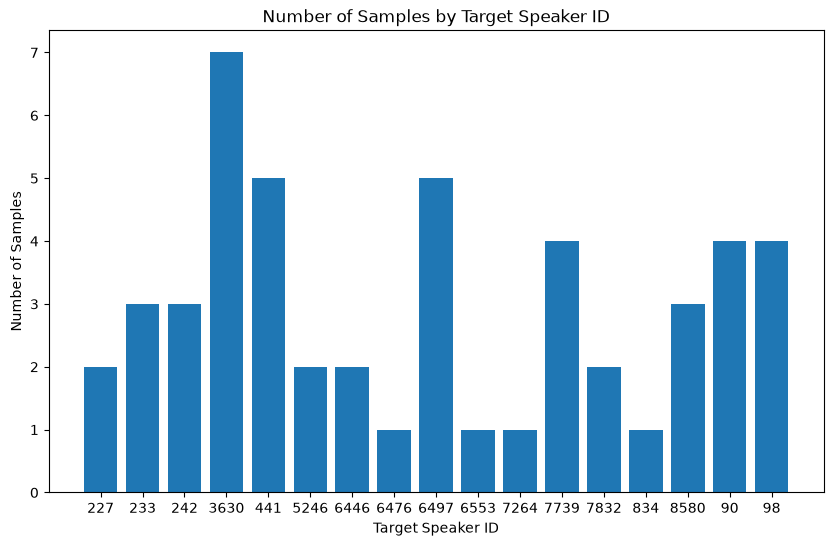

In [9]:
print(f"Number of samples: {len(D.df)}")
number_by_target_speaker = D.df.groupby('target_speaker').size().to_dict()
plt.figure(figsize=(10, 6))
plt.bar(number_by_target_speaker.keys(), number_by_target_speaker.values())
plt.xlabel('Target Speaker ID')
plt.ylabel('Number of Samples')
plt.title('Number of Samples by Target Speaker ID')
plt.show()

findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmti10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


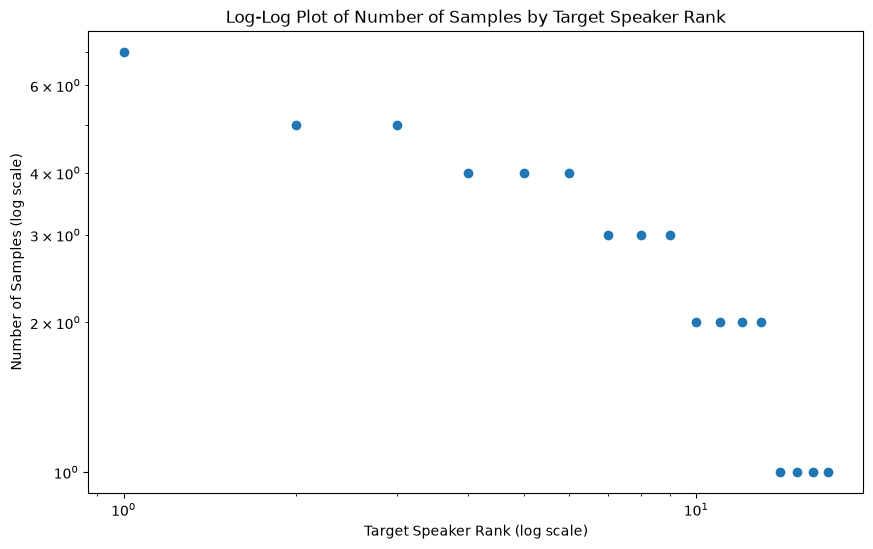

In [10]:
# log log plot of distribution of number of samples for target speaker rank
sorted_counts = sorted(number_by_target_speaker.items(), key=lambda x: x[1], reverse=True)
ranks = range(1, len(sorted_counts) + 1)
counts = [v for k, v in sorted_counts]
plt.figure(figsize=(10, 6))
plt.loglog(ranks, counts, marker='o', linestyle='None')
plt.xlabel('Target Speaker Rank (log scale)')
plt.ylabel('Number of Samples (log scale)')
plt.title('Log-Log Plot of Number of Samples by Target Speaker Rank')
plt.show()

## 2. Timing and overlap
### 2.1 `mixture_length_s`, `target_onset_s`, `interferer_onset_s`, `target_speech_s`, `target_activity`, `interferer_speech_s`, `interferer_activity`, `overlap_requested`, `overlap_achieved`

These columns are created using the following parameters to determine where the target will be speaking, for how long they will be speaking, where the interferer will speak, for how long will there be overlap between interefer and target:

- $\texttt{target\_activity\_ratio}: 0.75$ which is the goal for how long the target should ideally be speaking in the sample. This is the value that the paper $\textit{`REAL-TSE'}$ aimed for.
- $\texttt{activity\_tolerance}: 0.1$ how far above the goal the generator is allowed to land. Speech is built from WHOLE utterances, so there will be cases where we have longer speech so we have a range from 0.75-0.85 as a window. We will never consider lower.
- $\texttt{overlap\_ratio}: [0.2, 0.7]$ is drawn uniformly and represents the fraction of the window where both people are talking.
- $\texttt{overlap\_tolerance}: 0.03$ used for the interferer which is slid along the window to hit the requested overlap. 
- $\texttt{max\_utterances\_per\_source}: 8$ is the max number of consecutive utterances to make one speaker's speech, sp a source is never assembled from a long string of tiny fragments.

Therefore all of these columns are not independant draws and constrain each other arithmetically.


A big note, we only use one block to interfere with the target and not many places of interference. This does help simplify the train task, however, it does cost us realism. The hope is that these individual instances will translate to the many times we call on the model.

In [11]:
# only consider trials with a target speaker. Absent target trials have overlap 0 by definition
present = D.df[D.df['target_absent'] == 0]
print(f"Percentage of trials with a target speaker: {len(present)/len(D.df)*100:.2f}%")

Percentage of trials with a target speaker: 72.00%


#### Structural asymmetry

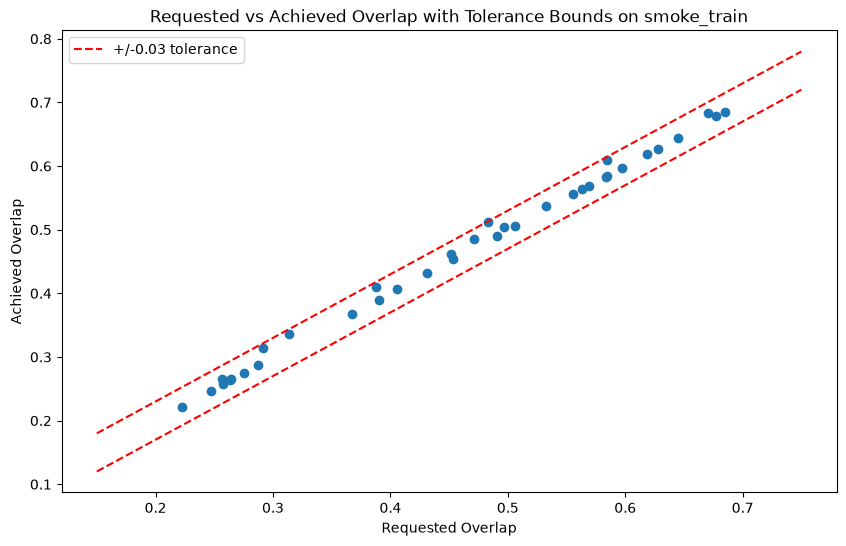

In [12]:
tolerance = D.cfg["overlap_tolerance"]
line = [0.15, 0.75]

plt.figure(figsize=(10, 6))
plt.scatter(present['overlap_requested'], present['overlap_achieved'])
plt.plot(line, [v + tolerance for v in line], color='red', linestyle='--', label=f'+/-{tolerance} tolerance')
plt.plot(line, [v - tolerance for v in line], color='red', linestyle='--')
plt.xlabel('Requested Overlap')
plt.ylabel('Achieved Overlap')
plt.title(f'Requested vs Achieved Overlap with Tolerance Bounds on {D.split}')
plt.legend()
plt.show()

In [13]:
miss = (present["overlap_achieved"] - present["overlap_requested"]).abs()
print(f"Worst miss: {miss.max():.4f}, Mean miss: {miss.mean():.4f}, Median miss: {miss.median():.4f}")
print(f"Acceptable hit percentages: {((miss <= tolerance).sum() / len(miss)) * 100:.2f}%")
print(f"Exact hit percentages: {((miss <= 1e-9).sum() / len(miss)) * 100:.2f}%")

Worst miss: 0.0287, Mean miss: 0.0052, Median miss: 0.0004
Acceptable hit percentages: 100.00%
Exact hit percentages: 22.22%


#### Activity, overlap and speech time

In [14]:
# activity 
difference = (present["target_activity"] - present["target_speech_s"]/ present["mixture_length_s"]).abs()
print(f"Worst activity difference: {difference.max():.4f}, Mean activity difference: {difference.mean():.4f}, Median activity difference: {difference.median():.4f}") 

Worst activity difference: 0.0001, Mean activity difference: 0.0000, Median activity difference: 0.0000


In [15]:
# speech time is sum of utterance durations
speech_time_diff = (present["target_speech_s"] - present["target_dur_list"].map(sum)).abs()
print(f"Worst speech time difference: {speech_time_diff.max():.4f}, Mean speech time difference: {speech_time_diff.mean():.4f}, Median speech time difference: {speech_time_diff.median():.4f}")  

Worst speech time difference: 0.0000, Mean speech time difference: 0.0000, Median speech time difference: 0.0000


In [16]:
# overlap is the shared time between two speaker talking intervals
worst = 0.0
for i, row in present.iterrows():
    shared_time = 0.0
    for t_start, t_end in spans(row, "target"):
        for i_start, i_end in spans(row, "interferer"):
            shared_time += max(0, min(t_end, i_end) - max(t_start, i_start))
    worst = max(worst, abs(shared_time / row["mixture_length_s"] - row["overlap_achieved"]))
print(f"Worst overlap difference: {worst:.4f}")

Worst overlap difference: 0.0001


Make a timeline plot for the first 3 trials with a target speaker, showing the target and interferer utterances as horizontal bars.

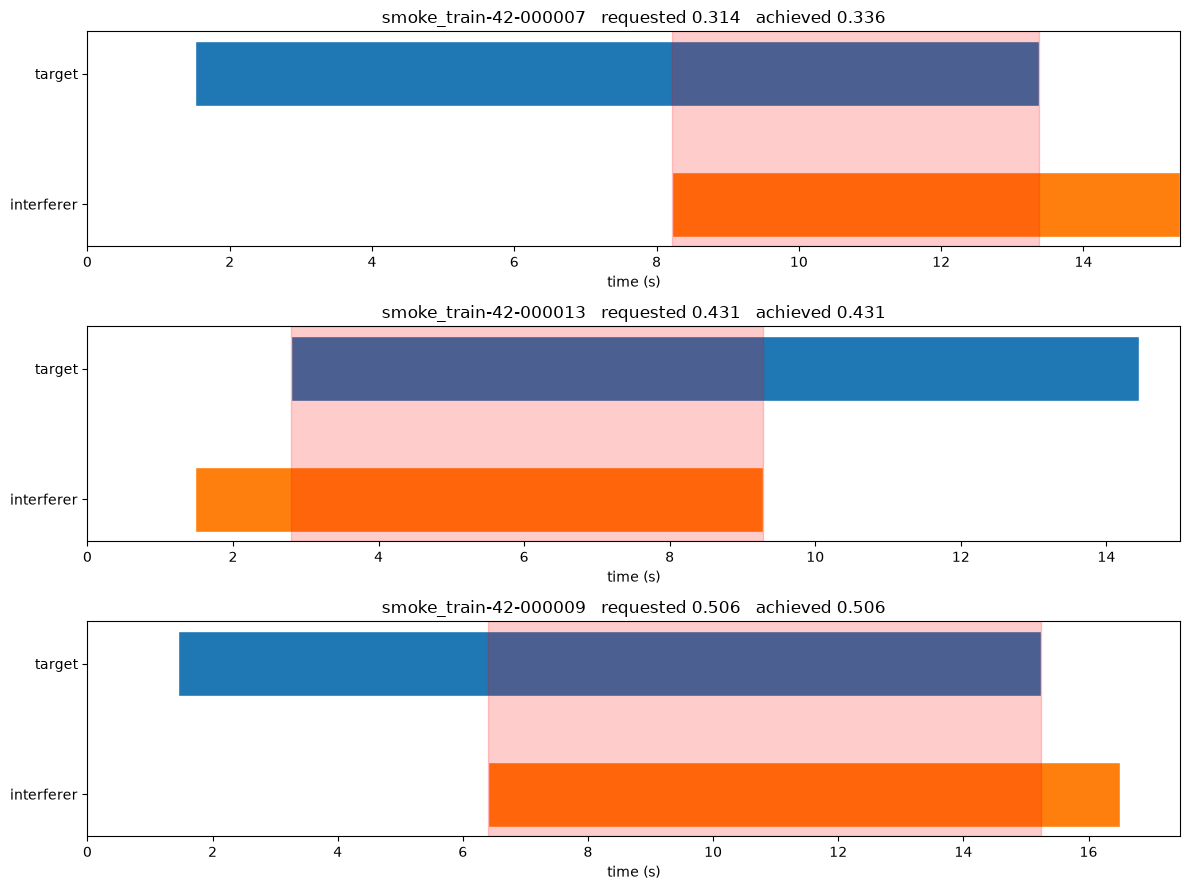

In [17]:
rows = 3
random_indices = np.random.choice(D.df.index, size=rows, replace=False)

fig, axes = plt.subplots(rows, 1, figsize=(12, 3 * rows))
if rows == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    random_index = random_indices[i]
    row = D.df.iloc[random_index]

    # target bars on the top row, interferer underneath.
    # white edges so back-to-back utterances stay visible as separate blocks.
    for start, end in spans(row, "target"):
        ax.barh(1, end - start, left=start, height=0.5,
                color="tab:blue", edgecolor="white")
    for start, end in spans(row, "interferer"):
        ax.barh(0, end - start, left=start, height=0.5,
                color="tab:orange", edgecolor="white")

    # shade every stretch where both are talking
    for t_start, t_end in spans(row, "target"):
        for i_start, i_end in spans(row, "interferer"):
            lo, hi = max(t_start, i_start), min(t_end, i_end)
            if hi > lo:
                ax.axvspan(lo, hi, color="red", alpha=0.2)

    ax.set_xlim(0, row["mixture_length_s"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["interferer", "target"])
    
    # Only label x-axis on the bottom plot to reduce clutter, or keep on all
    ax.set_xlabel("time (s)")
    ax.set_title(f"{row['trial_id']}   requested {row['overlap_requested']:.3f}   "
                 f"achieved {row['overlap_achieved']:.3f}")

plt.tight_layout()
plt.show()


### 3. Levels

#### `sir_db`, `snr_db`, `target_loudness_lufs` 
where the most notable thing is that the signal to interference ratio is always 0 dB when the target is absent. These features are controlled by the following parameter:
- $\texttt{clip\_ceiling}: 0.95$ which is responsible for the loudness of the target in the audio clip and is measured using BS.1770 as a loudness measure. 

Remember, a rendered trial consists of three audio segments: the target speaker, the interferer speaker, and the background noise. Each of these segments are mixed together, but we cannot assume that they will always be at the same level. To simplify our task, we define the target speaker's loudness using the LUFS (Loudness Units relative to Full Scale) standard, which we use as an anchor for the other segments. The signal-to-interference ratio (SIR) places the interferer relative to the target, and the signal-to-noise ratio (SNR) places the background noise relative to the target. A simple deduction is that the higher the db of the target, the easier the task.

**NOTE:** SIR and SNR effect the downstream ASR task differently NEGATIVELY and thus are two separate issues. These errors have different kind of errors in the output TEXT: 
- SIR: The louder this is, the more frequently we can expect insertions and substitutions of real words.
- SNR: This will cause more deletions and garbling where we can expect non-words and deletions.

We should use the SI-SDR metric to account for these damages as one unit.

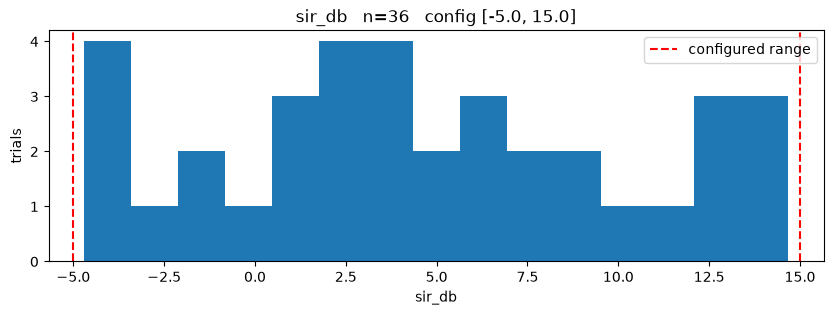

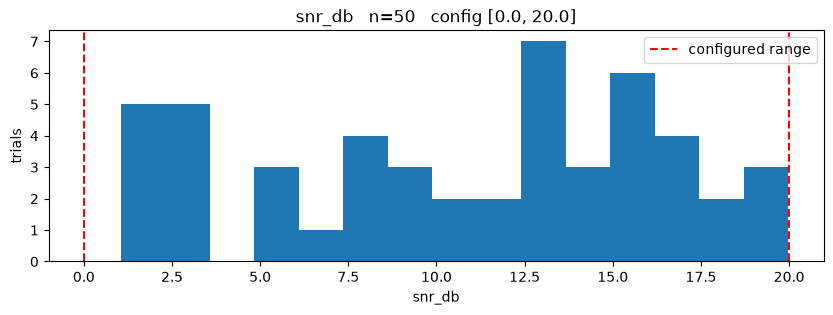

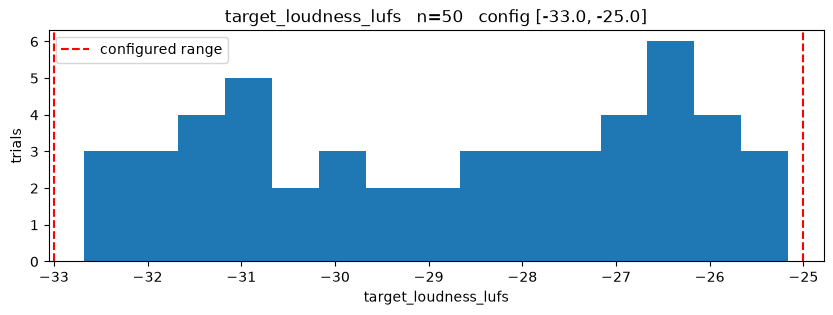

In [18]:
# does each level column cover the range the config asked for?
# no range= on the hist, so anything outside the configured range stays visible
for col in ["sir_db", "snr_db", "target_loudness_lufs"]:
    lo, hi = D.cfg[col]
    v = D.df[col].dropna()
    plt.figure(figsize=(10, 3))
    plt.hist(v, bins=15)
    plt.axvline(lo, color="red", linestyle="--")
    plt.axvline(hi, color="red", linestyle="--", label="configured range")
    plt.xlabel(col)
    plt.ylabel("trials")
    plt.title(f"{col}   n={len(v)}   config [{lo}, {hi}]")
    plt.legend()
    plt.show()


In [19]:
 # check independence
cols = ["sir_db", "snr_db", "target_loudness_lufs", "overlap_requested",
        "interferer_activity", "target_activity", "mixture_length_s", "t60_s"]
c = present[cols].corr()
floor = 2 / np.sqrt(len(present))

print(f"n = {len(present)}   noise floor |r| = {floor:.2f}")
print("pairs above the noise floor:")
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = c.iloc[i, j]
        if abs(r) > floor:
            print(f"   {cols[i]:22} {cols[j]:22} r = {r:+.2f}")


n = 36   noise floor |r| = 0.33
pairs above the noise floor:
   overlap_requested      interferer_activity    r = +0.95


The pairs that must never appear are sir_db, snr_db, overlap_* and t60_s against each other. Those four are your experimental axes. If any two of them correlate, then "WER degrades as SIR falls" becomes unprovable — you can't tell whether it was the SIR or the thing riding along with it.


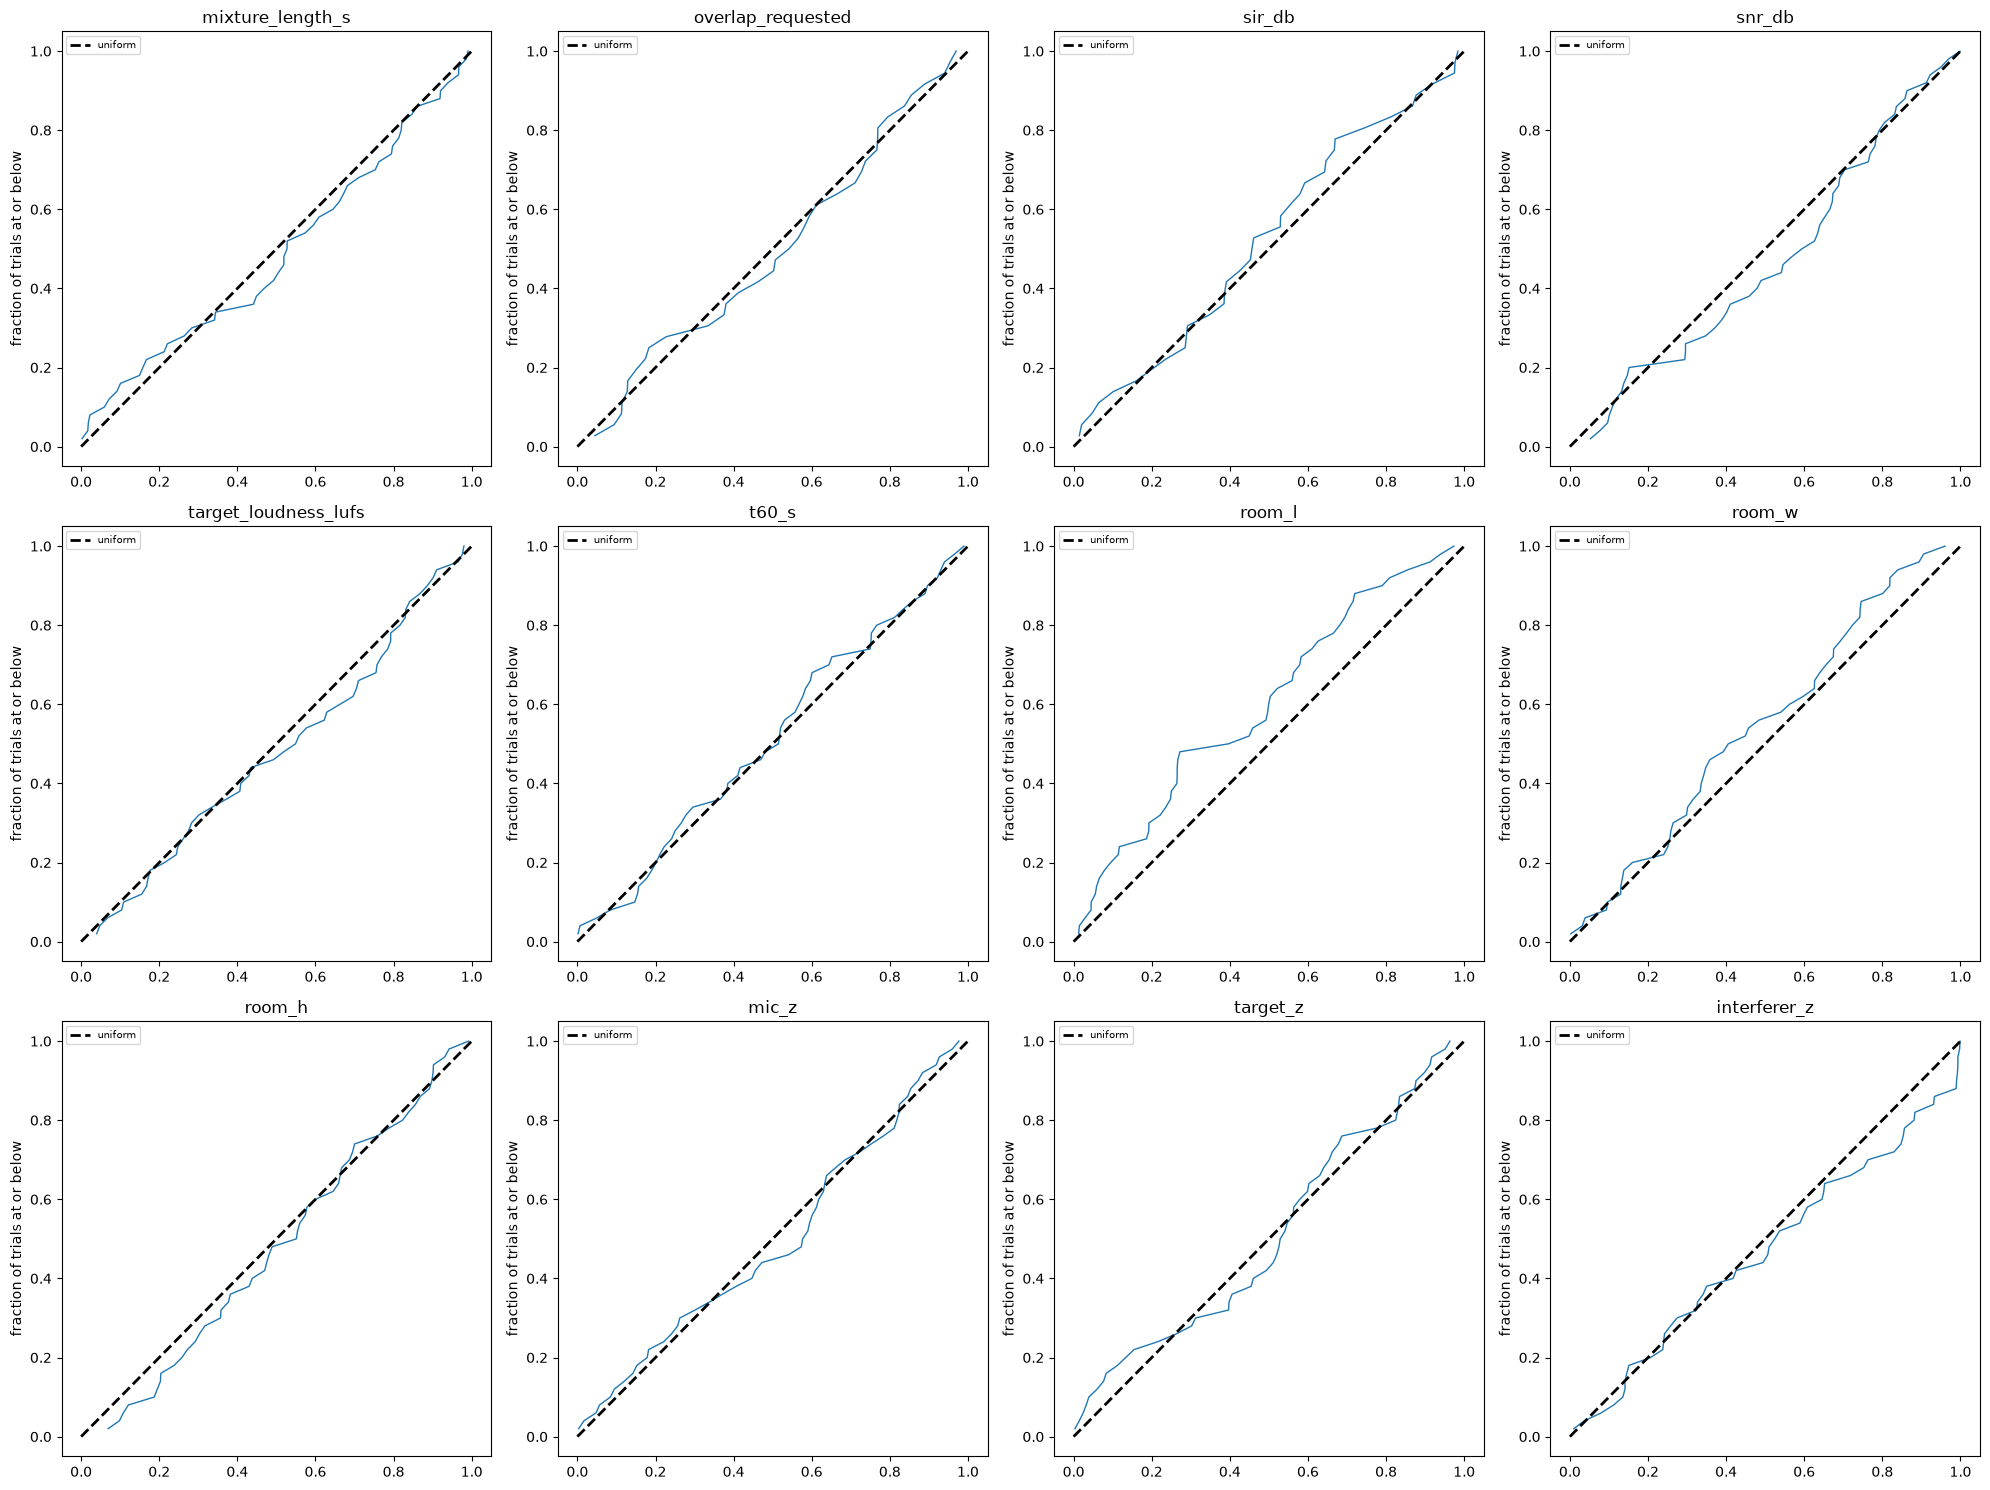

In [20]:
n = len(RANGES)
cols = min(n, 4)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = np.atleast_1d(axes).flatten()

for ax, (col, key) in zip(axes, RANGES.items()):
    lo, hi = D.cfg[key]
    v = D.df[col][D.df["target_absent"] == 0] if col == "overlap_requested" else D.df[col]
    v = np.sort(v.dropna())
    
    ax.plot((v - lo) / (hi - lo), np.arange(1, len(v) + 1) / len(v), linewidth=1)
    ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=2, label="uniform")
    
    ax.set_ylabel("fraction of trials at or below")
    
    # Column name instead of the generic title
    ax.set_title(col) 
    ax.legend(fontsize=7)

# Hide any empty subplots in the grid
for i in range(n, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

### 4. Room and reverberation


4.1 There are 13 independent room features that contribute to this audio setup. These variables include:
- `t60_s` is the time it takes for a room's echoes to decay by 60dB which I sample from [0.15, 0.6].
- `room_l/w/h`
- `mic_x/y/z`
- `target_x/y/z`
- `interferer_x/y/z`

which describe a shoebox room which is built with the $\texttt{pyroomacoustics}$ library. We place the mic and two sources at the given coordinates, set wall absorbtion so that the delay time from doppler effect is the `t60_s` value, and generate one room impulse response per source. We also make reverb to make the audio sound like a room rather than a recording booth. The most important thing is that ALL SPEAKERS IN A SAMPLE MUST BE IN THE SAME ROOM!

The procedure per source:
1. Draw a horizontal distance from the mic — source_distance_m: [0.66, 2.0] m, uniform.
2. Draw an azimuth uniformly over the full circle, 0 to 2π.
3. Convert to x/y by trigonometry around the mic: x = mic_x + d·cos(az), y = mic_y + d·sin(az).
4. Reject and redraw if the point lands within 0.3 m of any wall — up to 50 attempts, then raise.
5. Draw z independently from source_height_m: [0.9, 1.8] m. This is a separate draw, not derived from the distance.

The mic itself is placed first, in sample_room (lines 146–148): x and y uniform over the central 35–65% of each room dimension, z
from mic_height_m: [0.9, 1.8]. So the mic is always roughly central and the sources orbit it.


Distribution of t60_s


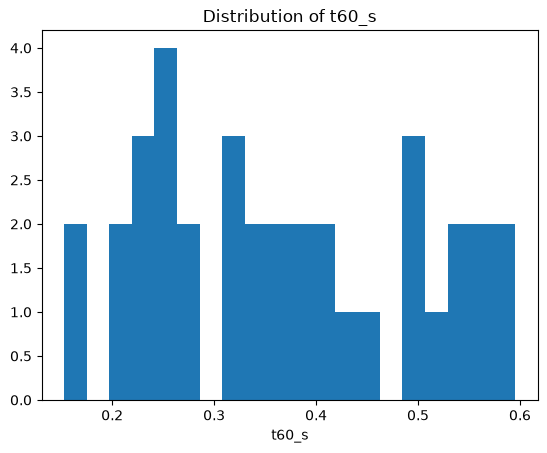

Number of trials with t60_s above 0.3s latency budget: 23 (63.89%)


In [21]:
print(f"Distribution of t60_s")
plt.hist(present["t60_s"], bins=20)
plt.title(f"Distribution of t60_s")
plt.xlabel("t60_s")
plt.show()

num_t_above_latency_budget = (present["t60_s"] > 0.3).sum()
print(f"Number of trials with t60_s above 0.3s latency budget: {num_t_above_latency_budget} "
      f"({num_t_above_latency_budget / len(present) * 100:.2f}%)")

**IDEA:** That is not a bug in the data. If your reference is direct + early 50 ms, the model is being trained to suppress a tail extending up to 600 ms into the future - from a 300 ms window. Either the task is partly ill-posed, or the model learns a **statistical prior over rooms** rather than actually cancelling the tail it can't see.

In [22]:
# geometry invariants -- all recomputed from the coordinates that were recorded
df = D.df
lo, hi = D.cfg["source_distance_m"]

for speaker in ["target", "interferer"]:
    dist = np.sqrt((df[f"{speaker}_x"] - df["mic_x"])**2 + (df[f"{speaker}_y"] - df["mic_y"])**2)
    
    # clearance to the nearest of the four walls
    wall = pd.concat([df[f"{speaker}_x"], df["room_l"] - df[f"{speaker}_x"], df[f"{speaker}_y"], df["room_w"] - df[f"{speaker}_y"]], axis=1).min(axis=1)
    print(f"{speaker:11} distance {dist.min():.2f}..{dist.max():.2f} m "
        f"(config [{lo}, {hi}])   min wall clearance {wall.min():.2f} m (rule 0.3)")
        
    assert (dist >= lo - 0.01).all() and (dist <= hi + 0.01).all()
    assert (wall >= 0.3).all()
    assert (df[f"{speaker}_z"] < df["room_h"]).all()

# T60 must be physically reachable in the room it was drawn for
vol = df["room_l"] * df["room_w"] * df["room_h"]
surf = 2 * (df["room_l"] * df["room_w"] + df["room_l"] * df["room_h"]
            + df["room_w"] * df["room_h"])
assert (df["t60_s"] >= 0.161 * vol / surf).all(), "T60 below the Sabine floor"

# the mic sits centrally by construction, never against a wall
print(f"mic at {(df['mic_x']/df['room_l']).min():.2f}.."
    f"{(df['mic_x']/df['room_l']).max():.2f} of room length (rule 0.35-0.65)")

print(f"\nT60 above the 0.3 s latency budget in {(df['t60_s'] > 0.3).mean():.0%} of trials")


target      distance 0.67..1.98 m (config [0.66, 2.0])   min wall clearance 0.38 m (rule 0.3)
interferer  distance 0.68..1.95 m (config [0.66, 2.0])   min wall clearance 0.50 m (rule 0.3)
mic at 0.36..0.65 of room length (rule 0.35-0.65)

T60 above the 0.3 s latency budget in 66% of trials


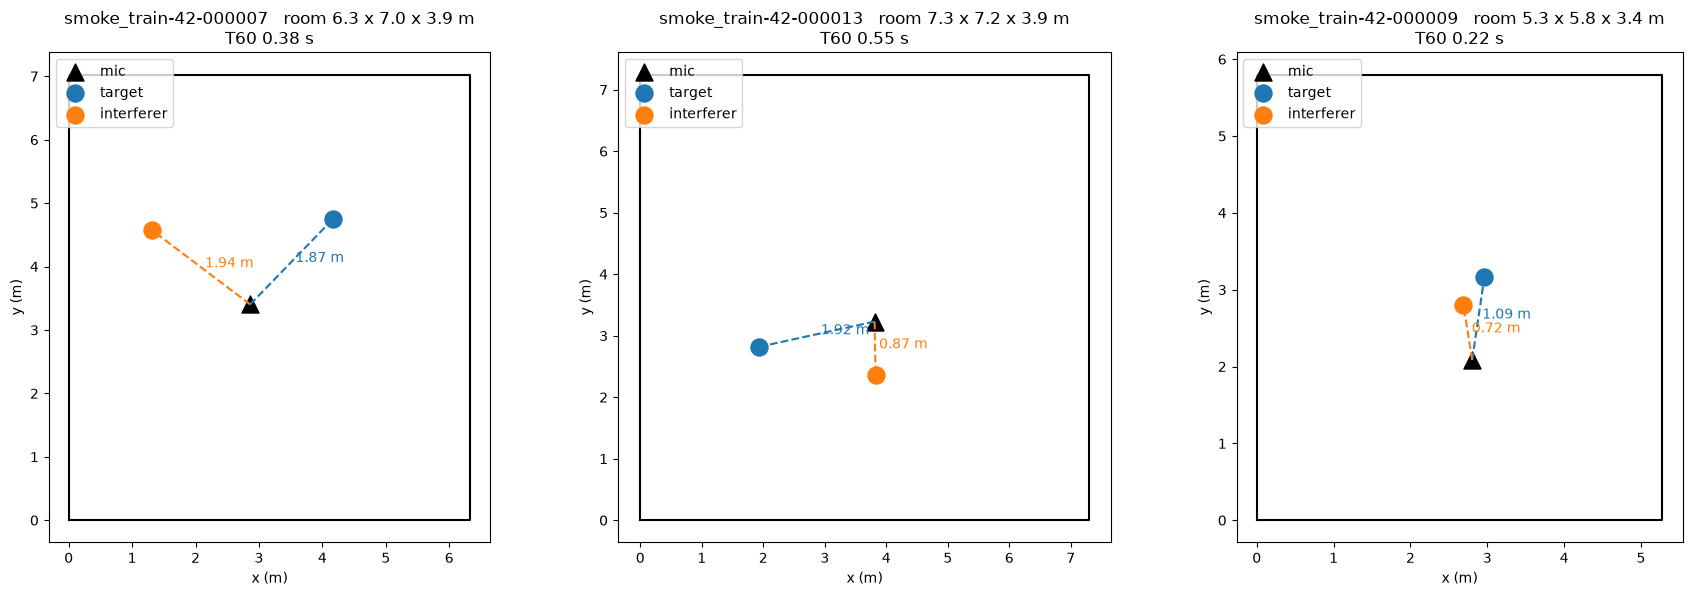

In [23]:
n_plots = len(random_indices)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 6))

# Ensure axes is iterable in case there is only 1 index
if n_plots == 1:
    axes = [axes]

for ax, i in zip(axes, random_indices):
    row = D.df.iloc[i]

    # Draw room boundaries
    ax.plot([0, row["room_l"], row["room_l"], 0, 0],
            [0, 0, row["room_w"], row["room_w"], 0], color="black")
    
    # Plot entities
    ax.scatter(row["mic_x"], row["mic_y"], marker="^", s=150, color="black", label="mic")
    ax.scatter(row["target_x"], row["target_y"], s=150, color="tab:blue", label="target")
    ax.scatter(row["interferer_x"], row["interferer_y"], s=150, color="tab:orange", label="interferer")

    # Dashed lines to the mic, labelled with the distance
    for who, colour in [("target", "tab:blue"), ("interferer", "tab:orange")]:
        ax.plot([row["mic_x"], row[f"{who}_x"]], [row["mic_y"], row[f"{who}_y"]],
                color=colour, linestyle="--")
        
        d = ((row[f"{who}_x"] - row["mic_x"])**2 + (row[f"{who}_y"] - row["mic_y"])**2) ** 0.5
        
        ax.text((row["mic_x"] + row[f"{who}_x"]) / 2,
                (row["mic_y"] + row[f"{who}_y"]) / 2, f" {d:.2f} m", color=colour)

    # Apply axis-level formatting outside the inner loop
    ax.set_aspect("equal")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    
    # Added a newline in the title so it doesn't overlap adjacent plots
    ax.set_title(f"{row['trial_id']}   room {row['room_l']:.1f} x {row['room_w']:.1f} x "
                 f"{row['room_h']:.1f} m\nT60 {row['t60_s']:.2f} s")
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

We want to check that the activity level of both the interferer and the target can be roughly the same. This is so that our model doesnt just guess one over the other based on duration and not on voice qualities.

In [24]:
absent = D.df[D.df["target_absent"] == 1]
present = D.df[D.df["target_absent"] == 0]

cols = ["t60_s", "snr_db", "target_loudness_lufs", "mixture_length_s",
        "room_l", "room_w", "room_h", "interferer_activity", "interferer_speech_s"]
print(f"{'column':22} {'present':>9} {'absent':>9} {'gap/sd':>8}")
for col in cols:
    sd = D.df[col].std()
    gap = (absent[col].mean() - present[col].mean()) / sd
    print(f"{col:22} {present[col].mean():9.2f} {absent[col].mean():9.2f} {gap:+8.2f}")



column                   present    absent   gap/sd
t60_s                       0.37      0.39    +0.16
snr_db                     11.05     10.28    -0.14
target_loudness_lufs      -28.68    -29.01    -0.14
mixture_length_s           17.67     17.43    -0.15
room_l                      6.77      7.74    +0.68
room_w                      7.11      7.79    +0.50
room_h                      3.54      3.50    -0.15
interferer_activity         0.57      0.80    +1.39
interferer_speech_s        10.20     14.01    +1.23


Anything past about 1 sd is a giveaway worth chasing.

In [25]:
# --- 4.4  is T60 physically reachable, and did the rejection loop bend anything?
vol = D.df["room_l"] * D.df["room_w"] * D.df["room_h"]
surf = 2 * (D.df["room_l"]*D.df["room_w"] + D.df["room_l"]*D.df["room_h"]
            + D.df["room_w"]*D.df["room_h"])
sabine_floor = 0.161 * vol / surf  # T60 with perfectly absorbing walls

print(f"room volume {vol.min():.0f}..{vol.max():.0f} m3")
print(f"sabine floor on T60 {sabine_floor.min():.3f}..{sabine_floor.max():.3f} s")
print(f"config asks from {D.cfg['t60_s'][0]} s -- infeasible in the larger rooms")
print(f"trials below the floor: {(D.df['t60_s'] < sabine_floor).sum()} (must be 0)")

# the rejection loop could bias t60 towards small rooms. quartiles are a far
# better test of that than a correlation at this sample size.
lo, hi = D.cfg["t60_s"]
print(f"\nt60 quartiles  {np.percentile(D.df['t60_s'], [0,25,50,75,100]).round(3)}")
print(f"uniform gives  {np.percentile(np.linspace(lo,hi,10000), [0,25,50,75,100]).round(3)}")
print(f"corr(t60, volume) = {np.corrcoef(D.df['t60_s'], vol)[0,1]:+.2f}"
    f"   noise floor {2/np.sqrt(len(D.df)):.2f}")

# --- 4.5  the configured distance is horizontal; the true 3-D distance differs
for who in ["target", "interferer"]:
    horiz = np.sqrt((D.df[f"{who}_x"] - D.df["mic_x"])**2
                    + (D.df[f"{who}_y"] - D.df["mic_y"])**2)
    true3d = np.sqrt(horiz**2 + (D.df[f"{who}_z"] - D.df["mic_z"])**2)
    print(f"{who:11} horizontal {horiz.min():.2f}..{horiz.max():.2f}   "
        f"true 3-D {true3d.min():.2f}..{true3d.max():.2f}   "
        f"config {D.cfg['source_distance_m']}")

# in mono there is no spatial cue, so two speakers standing close is harmless
sep = np.sqrt((D.df["target_x"] - D.df["interferer_x"])**2
            + (D.df["target_y"] - D.df["interferer_y"])**2)
print(f"speaker separation {sep.min():.2f}..{sep.max():.2f} m, "
    f"under 0.5 m in {(sep < 0.5).sum()} trials") 

room volume 82..296 m3
sabine floor on T60 0.113..0.165 s
config asks from 0.15 s -- infeasible in the larger rooms
trials below the floor: 0 (must be 0)

t60 quartiles  [0.151 0.26  0.382 0.488 0.595]
uniform gives  [0.15  0.262 0.375 0.488 0.6  ]
corr(t60, volume) = -0.15   noise floor 0.28
target      horizontal 0.67..1.98   true 3-D 0.67..1.98   config [0.66, 2.0]
interferer  horizontal 0.68..1.95   true 3-D 0.68..2.06   config [0.66, 2.0]
speaker separation 0.30..3.19 m, under 0.5 m in 3 trials


### 5. Enrollment and pairing
5.1 Enrollment criteria are combined to ensure that the only way to complete the task is by actually listening to the voice. The following variables act as a safe guard against finding features that the model can leverage that will prevent it from learning things that are not the voice of the target (and to prioritise it).

- `enrollment_utt`
- `enrollment_offset_s`
- `enrollment_length_s`
- `enrollment_eq`
- `target_speaker`
- `interferer_speaker`
- `target_chapter`
- `interferer_chapter`
- `same_gender`

In [26]:
# LibriSpeech metadata: which speaker is which sex, which chapter is which book
ls = ROOT / "data/librispeech/LibriSpeech"
sex, book = {}, {}
for line in (ls / "SPEAKERS.TXT").read_text(errors="replace").splitlines():
    if line.lstrip().startswith(";") or not line.strip():
        continue
    f = [p.strip() for p in line.split("|")]
    sex[f[0]] = f[1]
for line in (ls / "CHAPTERS.TXT").read_text(errors="replace").splitlines():
    if line.lstrip().startswith(";") or not line.strip():
        continue
    f = [p.strip() for p in line.split("|")]
    book[f[0]] = f[5]

present = D.df[D.df["target_absent"] == 0]
target_book = present["target_chapter"].map(book)
enroll_chapter = present["enrollment_utt"].str.split("-").str[1]

print(f"target != interferer         "
    f"{(D.df['target_speaker'] != D.df['interferer_speaker']).all()}")
print(f"different books               "
    f"{(target_book != present['interferer_chapter'].map(book)).all()}")
print(f"enrollment chapter differs    {(enroll_chapter != present['target_chapter']).all()}")
print(f"enrollment BOOK differs       {(enroll_chapter.map(book) != target_book).all()}"
    f"   same book in {(enroll_chapter.map(book) == target_book).sum()} trials")

# same_gender must agree with the actual metadata, not just the intended rate
actual = (D.df["target_speaker"].map(sex) == D.df["interferer_speaker"].map(sex))
print(f"same_gender flag is truthful  {(D.df['same_gender'] == actual.astype(int)).all()}")

# the enrollment window must fit inside its clip
edur = D.df["enrollment_utt"].map(D.utts["duration"].to_dict())
print(f"enrollment window fits        "
    f"{((D.df['enrollment_offset_s'] + D.df['enrollment_length_s']) <= edur + 1e-6).all()}")
print(f"enrollment clips all >= 5 s   {(edur >= D.df['enrollment_length_s']).all()}")


target != interferer         True
different books               True
enrollment chapter differs    True
enrollment BOOK differs       False   same book in 11 trials
same_gender flag is truthful  True
enrollment window fits        True
enrollment clips all >= 5 s   True


In [27]:
# is the enrollment offset uniform in the room available to it? We want to check if the enrollment offset is uniformly distributed within the available room of the enrollment clip. The available room is calculated as the duration of the enrollment utterance minus the length of the enrollment segment. We then compute the fraction of the enrollment offset relative to this available room and check its mean value. A uniform distribution would have a mean of 0.5.
edur = D.df["enrollment_utt"].map(D.utts["duration"].to_dict())
room = edur - D.df["enrollment_length_s"]

print(f"\noffset as fraction of available room: mean "
    f"{(D.df['enrollment_offset_s'] / room).mean():.3f} (uniform -> 0.500)")


offset as fraction of available room: mean 0.396 (uniform -> 0.500)


In [28]:
# speaker usage balance, target and interferer. We want to check if the generator is over-using a few speakers and under-using others.
print(f"target usage:     {D.df['target_speaker'].nunique()} distinct, "
    f"{D.df['target_speaker'].value_counts().min()}.."
    f"{D.df['target_speaker'].value_counts().max()} trials each")
print(f"interferer usage: {D.df['interferer_speaker'].nunique()} distinct, "
    f"{D.df['interferer_speaker'].value_counts().min()}.."
    f"{D.df['interferer_speaker'].value_counts().max()} trials each")


target usage:     17 distinct, 1..7 trials each
interferer usage: 19 distinct, 1..5 trials each


### 6. Noise

#### 6.1 Check that the noise bed level is within the configured range
- `noise_clip`
- `noise_offset_s`

In [29]:
# every clip named must exist in the index for this split's noise set
known = set(D.noise.index)
missing = set(D.df["noise_clip"]) - known
print(f"noise split '{D.cfg['noise_split']}': {len(known)} clips in the index")
print(f"clips named by the manifest but absent from that index: {len(missing)}\n")

#  no clip may be shared between a training and an evaluation manifest.               
train_clips = set(load("smoke_train").df["noise_clip"])
val_clips = set(load("smoke_val").df["noise_clip"])
print(f"clips shared between smoke_train and smoke_val: {len(train_clips & val_clips)}\n")

# is there enough noise left in the clip to cover the mixture?
clipdur = D.df["noise_clip"].map(D.noise["duration"].to_dict())
remaining = clipdur - D.df["noise_offset_s"]
print(f"\nclip durations {clipdur.min():.1f}..{clipdur.max():.1f} s "
    f"(median {clipdur.median():.1f})")
print(f"mixtures       {D.df['mixture_length_s'].min():.1f}.."
    f"{D.df['mixture_length_s'].max():.1f} s")
print(f"trials needing more noise than the clip has left: "
    f"{(remaining < D.df['mixture_length_s']).sum()}/{len(D.df)}")
print(f"trials where the whole clip is shorter than the mixture: "
    f"{(clipdur < D.df['mixture_length_s']).sum()}/{len(D.df)}\n")

# how much of the library would survive a "long enough clips only" rule?
d = D.noise["duration"]
for t in [15.0, 20.0]:
    print(f"clips >= {t:4.1f} s: {(d >= t).sum():5} of {len(d)} ({(d >= t).mean():.2%})")


noise split 'tr': 20000 clips in the index
clips named by the manifest but absent from that index: 0

clips shared between smoke_train and smoke_val: 0


clip durations 6.5..17.5 s (median 10.4)
mixtures       15.0..20.0 s
trials needing more noise than the clip has left: 50/50
trials where the whole clip is shorter than the mixture: 50/50

clips >= 15.0 s:  1462 of 20000 (7.31%)
clips >= 20.0 s:    86 of 20000 (0.43%)


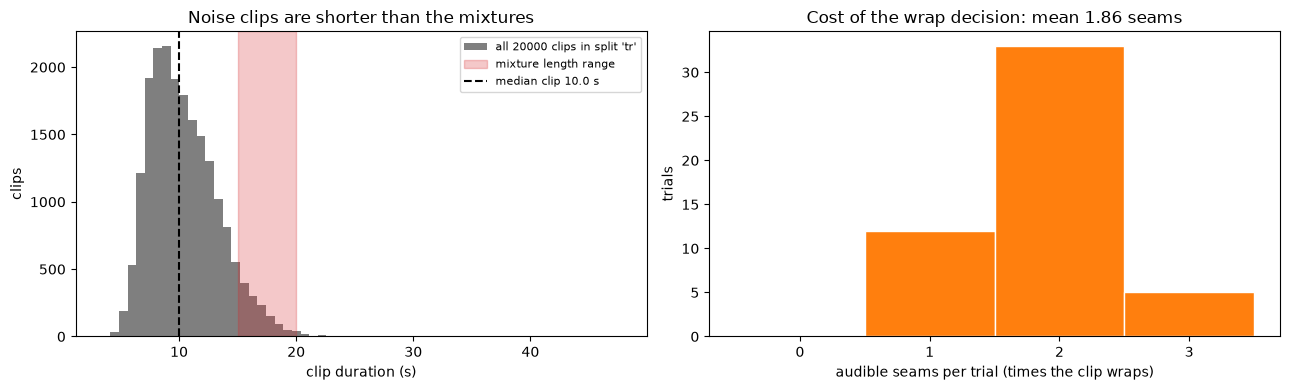

In [30]:
clipdur = D.df["noise_clip"].map(D.noise["duration"].to_dict())
# how many times the read pointer crosses the end of the clip
seams = np.floor((D.df["noise_offset_s"] + D.df["mixture_length_s"]) / clipdur)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(D.noise["duration"], bins=60, color="tab:grey",
        label=f"all {len(D.noise)} clips in split '{D.cfg['noise_split']}'")
ax1.axvspan(D.df["mixture_length_s"].min(), D.df["mixture_length_s"].max(),
            color="tab:red", alpha=0.25, label="mixture length range")
ax1.axvline(D.noise["duration"].median(), color="black", linestyle="--",
            label=f"median clip {D.noise['duration'].median():.1f} s")
ax1.set_xlabel("clip duration (s)")
ax1.set_ylabel("clips")
ax1.set_title("Noise clips are shorter than the mixtures")
ax1.legend(fontsize=8)

ax2.hist(seams, bins=np.arange(-0.5, seams.max() + 1.5), color="tab:orange",
        edgecolor="white")
ax2.set_xlabel("audible seams per trial (times the clip wraps)")
ax2.set_ylabel("trials")
ax2.set_xticks(range(int(seams.max()) + 1))
ax2.set_title(f"Cost of the wrap decision: mean {seams.mean():.2f} seams")

plt.tight_layout()
plt.show()


## Final healthchecks

In [ ]:
def check(D):
    df = D.df
    present = df[df["target_absent"] == 0]

    fails = []

    def ok(name, passed, detail=""):
        print(f"  {'PASS' if passed else 'FAIL'}  {name}   {detail}")
        if not passed:
            fails.append(name)

    print(f"{D.split}: {len(df)} trials, {len(present)} with the target present")

    ok("trial_ids unique", df["trial_id"].is_unique)
    ok("target never equals interferer",
        (df["target_speaker"] != df["interferer_speaker"]).all())
    ok("sir_db null exactly when target absent",
        (df["sir_db"].isna() == (df["target_absent"] == 1)).all())
    ok("enrollment speaker is the target",
        (df["enrollment_utt"].str.split("-").str[0] == df["target_speaker"]).all())
    ok("enrollment chapter differs from mixture chapter",
        (present["enrollment_utt"].str.split("-").str[1] != present["target_chapter"]).all())

    # every sampled column inside the range the config asked for
    for col, key in RANGES.items():
        lo, hi = D.cfg[key]
        v = df[col][df["target_absent"] == 0] if col == "overlap_requested" else df[col]
        v = v.dropna()
        ok(f"{col} within [{lo}, {hi}]", ((v >= lo - 1e-6) & (v <= hi + 1e-6)).all(),
            f"observed {v.min():.3f}..{v.max():.3f}, covers {(v.max()-v.min())/(hi-lo):.0%}")

    # derived columns must agree with what produced them
    d = (present["target_activity"]
        - present["target_speech_s"] / present["mixture_length_s"]).abs()
    ok("activity == speech_s / length", d.max() < 1e-3, f"worst {d.max():.1e}")
    d = (present["target_speech_s"] - present["target_dur_list"].map(sum)).abs()
    ok("speech_s == sum(durations)", d.max() < 1e-3, f"worst {d.max():.1e}")

    worst_ov, worst_end = 0.0, -9.9
    for _, row in df.iterrows():
        shared = 0.0
        for t_start, t_end in spans(row, "target"):
            for i_start, i_end in spans(row, "interferer"):
                shared += max(0.0, min(t_end, i_end) - max(t_start, i_start))

        worst_ov = max(worst_ov, abs(shared / row["mixture_length_s"]
                                    - row["overlap_achieved"]))
        ends = [e for who in ("target", "interferer") for _, e in spans(row, who)]
        worst_end = max(worst_end, max(ends) - row["mixture_length_s"])
    ok("overlap_achieved recomputes", worst_ov < 1e-3, f"worst {worst_ov:.1e}")

    miss = (present["overlap_achieved"] - present["overlap_requested"]).abs()
    ok("overlap miss within tolerance", miss.max() <= D.cfg["overlap_tolerance"] + 1e-9,
        f"worst {miss.max():.4f} of {D.cfg['overlap_tolerance']}")
    # 1 ms, not 1 us -- see the note below
    ok("no source runs past the window", worst_end < 1e-3,
        f"worst overshoot {worst_end*1000:+.3f} ms")

    lo, hi = D.cfg["source_distance_m"]
    for who in ("target", "interferer"):
        dist = np.sqrt((df[f"{who}_x"] - df["mic_x"])**2
                        + (df[f"{who}_y"] - df["mic_y"])**2)
        wall = pd.concat([df[f"{who}_x"], df["room_l"] - df[f"{who}_x"],
                        df[f"{who}_y"], df["room_w"] - df[f"{who}_y"]],
                        axis=1).min(axis=1)
        ok(f"{who} distance in [{lo}, {hi}]",
            ((dist >= lo - 0.01) & (dist <= hi + 0.01)).all(),
            f"{dist.min():.2f}..{dist.max():.2f}")
        ok(f"{who} clears every wall by 0.3 m", (wall >= 0.3).all(), f"min {wall.min():.2f}")
        ok(f"{who} below the ceiling", (df[f"{who}_z"] < df["room_h"]).all())

    vol = df["room_l"] * df["room_w"] * df["room_h"]
    surf = 2 * (df["room_l"]*df["room_w"] + df["room_l"]*df["room_h"]
                + df["room_w"]*df["room_h"])
    ok("t60 reachable in its room (Sabine)", (df["t60_s"] >= 0.161 * vol / surf).all())

    print("\n  warnings (true of the data, not yet decided in the design)")
    print(f"    no T60 reserve: t60 reaches {df['t60_s'].max():.2f} s and the last "
        f"source ends {-worst_end*1000:.0f} ms before the window closes")
    print(f"    absent fraction {(df['target_absent']==1).mean():.2f} vs configured "
        f"{D.cfg['target_absent_fraction']}")
    print(f"\n  {len(fails)} failed" if fails else "\n  all checks passed")
    return fails


check(load("smoke_train"))
check(load("smoke_val"))
